# Comparison to TOPEX spectra

In [1]:
import glob
import os
import warnings
from collections import defaultdict
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe


from swot_analysis import compute_pass_spectra
from swot_analysis import load_swot_l2_expert 

## 1. Configuration


In [22]:
# ── Input files ───────────────────────────────────────────────────────────────
DATA_DIR    = '/Volumes/PortableSSD/'#'/Users/zoecas/Documents/data/'
#DATA_DIR    = '/Users/zoecas/Documents/data/'

DATA_SUBDIR = 'diags_2024/'
filename_pattern = '1000km_2deg_demean.nc'

# ── Region of interest ────────────────────────────────────────────────────────
LAT_MIN, LAT_MAX = -60.0,60.0
LON_MIN, LON_MAX = 0.0,360.0

# ── Spectral parameters ───────────────────────────────────────────────────────
SEGMENT_LENGTH_KM = 500.0
OVERLAP           = 0.5
MAX_GAP_FRACTION  = 0.25

# ── Box size ──────────────────────────────────────────────────────────────────
BOX_DEG = 10.0

# ── Expert-product variable names ─────────────────────────────────────────────
SSH_VAR = 'ssha_karin_2'
HRET    = False   # add internal tide correction (height_cor_xover + internal_tide_hret)



## 3. Defining functions
Identical to GSER_SSH_spectra.ipynb (`segments_to_dataset`, `build_box_dataset`).

In [23]:
def build_box_dataset(ds_segments: xr.Dataset,
                      box_deg: float = 2.0,
                      min_sampling_fraction: float = 0.5) -> xr.Dataset:

    from collections import defaultdict

    lat     = ds_segments['lat_mean'].values
    lon     = ds_segments['lon_mean'].values
    lat_idx = np.floor(lat / box_deg).astype(int)
    lon_idx = np.floor(lon / box_deg).astype(int)

    box_to_segs = defaultdict(list)
    for i, key in enumerate(zip(lat_idx, lon_idx)):
        box_to_segs[key].append(i)

    psd_all    = ds_segments['psd'].values
    wavenumber = ds_segments['wavenumber'].values
    rows_lat, rows_lon, rows_n, rows_psd = [], [], [], []

    for (li, loi), idxs in sorted(box_to_segs.items()):
        rows_psd.append(np.nanmean(psd_all[idxs, :], axis=0))
        rows_n.append(len(idxs))
        rows_lat.append((li  + 0.5) * box_deg)
        rows_lon.append((loi + 0.5) * box_deg)

    n_segments = np.array(rows_n)
    n_max      = n_segments.max()
    keep       = n_segments >= min_sampling_fraction * n_max

    psd_stack  = np.stack(rows_psd, axis=0)
    lat_center = np.array(rows_lat)
    lon_center = np.array(rows_lon)

    return xr.Dataset(
        data_vars=dict(
            mean_psd=(['box', 'wavenumber'], psd_stack[keep],
                      {'long_name': 'Box-mean SSH(A) PSD', 'units': 'm^2 / (cycles/km)'}),
            n_segments=(['box'], n_segments[keep]),
            sampling_fraction=(['box'], n_segments[keep] / n_max),
            lat_center=(['box'], lat_center[keep], {'units': 'degrees_north'}),
            lon_center=(['box'], lon_center[keep], {'units': 'degrees_east'}),
        ),
        coords=dict(
            wavenumber=('wavenumber', wavenumber, {'units': 'cycles/km'}),
            box=('box', np.arange(keep.sum())),
        ),
        attrs=dict(box_size_deg=box_deg,
                   min_sampling_fraction=min_sampling_fraction),
    )

## Build segment and box datasets
Identical to GSER_SSH_spectra.ipynb from here onward.

In [24]:
ds_segments = xr.open_dataset(DATA_DIR+DATA_SUBDIR+'swot_segments_'+filename_pattern)

print(f'Segment dataset: {ds_segments.sizes}')

#ds_boxes = build_box_dataset(ds_segments, box_deg=BOX_DEG,min_sampling_fraction=0.15)
ds_boxes = xr.open_dataset(DATA_DIR+DATA_SUBDIR+'swot_box_spectra_'+filename_pattern)


print(f'Box dataset: {ds_boxes.sizes["box"]} boxes with at least 1 segment')

if ds_boxes.box_size_deg!=BOX_DEG:
    print(f'Box sizes do not match: {ds_boxes.box_size_deg} instead of {BOX_DEG}')
    ds_boxes = build_box_dataset(ds_segments, box_deg=BOX_DEG,min_sampling_fraction=0.15)

## comparing to smaller scales PSD
comparing = False
if comparing:
    ds_segments_250 = xr.open_dataset(DATA_DIR+DATA_SUBDIR+'swot_segments_250km_2deg_demean.nc')
    ds_boxes_250 = build_box_dataset(ds_segments_250, box_deg=BOX_DEG,min_sampling_fraction=0.15)

Segment dataset: Frozen({'segment': 335806, 'wavenumber': 251})
Box dataset: 7507 boxes with at least 1 segment
Box sizes do not match: 2.0 instead of 10.0


## Diagnostics

In [25]:
print('Segments per swath:')
for sw in ('left', 'right'):
    n = int((ds_segments['swath'] == sw).sum())
    print(f'  {sw}: {n}')

unique_granules = len(np.unique(ds_segments['granule'].values))
print(f'Unique granules contributing segments: {unique_granules}')
print(f'Boxes with ≥  5 segments: {int((ds_boxes["n_segments"] >=  5).sum())}')
print(f'Boxes with ≥ 10 segments: {int((ds_boxes["n_segments"] >= 10).sum())}')
print(f'Max segments in a box:    {int(ds_boxes["n_segments"].max())}')

Segments per swath:
  left: 166112
  right: 169694
Unique granules contributing segments: 9996
Boxes with ≥  5 segments: 328
Boxes with ≥ 10 segments: 328
Max segments in a box:    1406


In [26]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker


def plot_box(var : np.array, lon : np.array, lat : np.array,
             projection : ccrs = ccrs.Robinson(), cmap : str="viridis", 
             min_size : int=20, max_size : int=300, figsize : tuple=(14, 7),
             title : str = "Number of observations per box", label : str = "Number of observations",
             norm : norm = None, vmin : float = None, vmax : float = None
            ):

    mask = np.isfinite(var)
    lon = lon[mask]
    lat = lat[mask]
    var = var[mask]

    fig = plt.figure(figsize=figsize)
    ax = plt.axes(projection=projection)
    ax.set_global()
    ax.add_feature(cfeature.LAND,facecolor="0.9",edgecolor="none")
    ax.add_feature(cfeature.COASTLINE,linewidth=0.6)
    ax.add_feature(cfeature.BORDERS,linewidth=0.3)
    gl = ax.gridlines(draw_labels=True,linewidth=0.3,linestyle="--",alpha=0.5)
    
    gl.top_labels = False
    gl.right_labels = False

    gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 60))
    gl.ylocator = mticker.FixedLocator(np.arange(-60, 61, 30))

    gl.xlabel_style = {"size": 10,"color": "black",}

    gl.ylabel_style = {"size": 10,"color": "black",}
    
    if norm is not None:
        sc = ax.scatter(lon,lat,s=45,c=var,
                    cmap=cmap,edgecolors=None,linewidths=0.25,
                    transform=ccrs.PlateCarree(),norm = norm)
    else:
        if vmin is None:
            vmin,vmax=np.nanmin(var),np.nanmax(var)
            
        sc = ax.scatter(lon,lat,s=45,c=var,
                        cmap=cmap,edgecolors=None,linewidths=0.25,
                        transform=ccrs.PlateCarree(),vmin = vmin, vmax = vmax)

    cb = plt.colorbar(sc,ax=ax,shrink=0.7,pad=0.03)
    cb.set_label(label)
    ax.set_title(title)
    
    return fig, ax

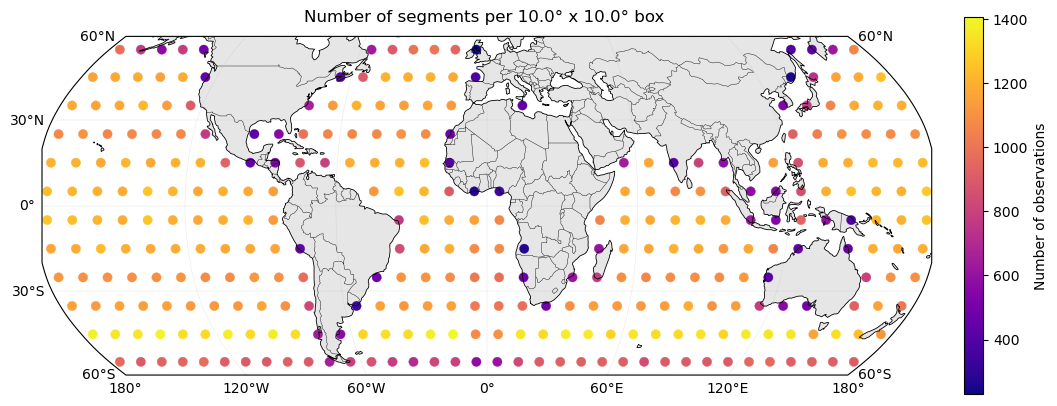

In [27]:
fig, ax = plot_box(ds_boxes["n_segments"].values,
                   ds_boxes["lon_center"].values,
                   ds_boxes["lat_center"].values,
                   #projection=ccrs.EqualEarth(),
                   cmap="plasma", title=f"Number of segments per {BOX_DEG:.1f}° x {BOX_DEG:.1f}° box ")
ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
plt.show()

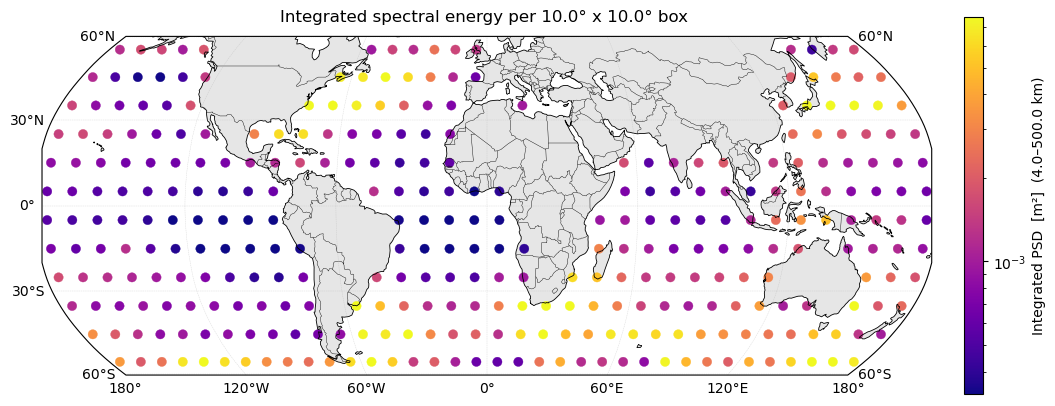

In [28]:
K_MIN, K_MAX = 1/500, 1/4
k      = ds_boxes['wavenumber'].values
k_mask = (k >= K_MIN) & (k <= K_MAX)
dk     = np.gradient(k)
energy = np.nansum(ds_boxes['mean_psd'].values[:, k_mask] * dk[k_mask], axis=1)

fig, ax = plot_box(energy,ds_boxes["lon_center"].values,ds_boxes["lat_center"].values,
                   cmap="plasma", title=f"Integrated spectral energy per {BOX_DEG:.1f}° x {BOX_DEG:.1f}° box ",
                   label=f'Integrated PSD  [m²]  ({1/K_MAX:.1f}–{1/K_MIN:.1f} km)',
                  norm=mcolors.LogNorm(vmin=np.nanpercentile(energy, 5),
                                       vmax=np.nanpercentile(energy, 95)))
ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
plt.show()

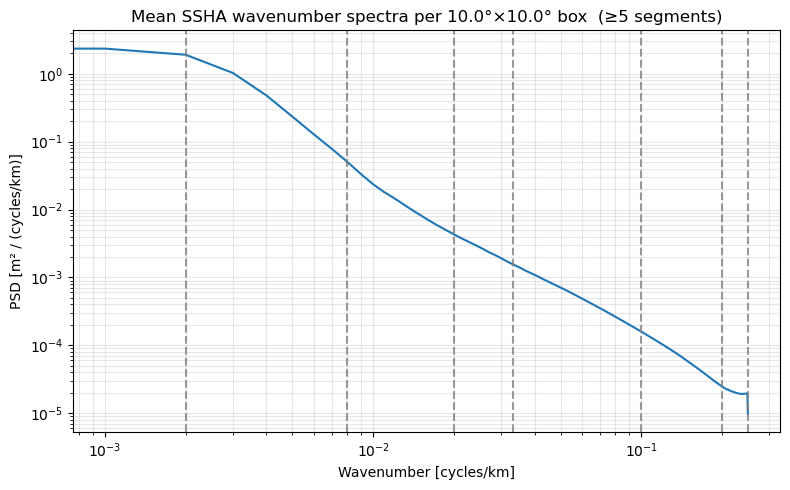

In [29]:
#Defining wavelengths of interest (very naive version)
MIN_SEGMENTS_PER_BOX = 5

mean_psd = ds_boxes.mean_psd.mean('box')

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(mean_psd["wavenumber"], mean_psd)

if comparing:
    mean_psd_250 = ds_boxes_250.mean_psd.mean('box')
    ax.loglog(mean_psd_250["wavenumber"], mean_psd_250)

# Reference slopes
if False:
    k_ref = good_boxes["wavenumber"].values[2:]
    psd0  = float(good_boxes["mean_psd"].isel(box=0).values[2])
    k0    = k_ref[0]
    for exp, ls in ((-2, "--"), (-11/3, ":"),(-5,"+-")):
        lbl = f"$k^{{{exp:.2g}}}$".replace("-3.7", "-11/3")
        ax.loglog(k_ref, psd0 * (k_ref / k0) ** exp, ls, color="gray", label=lbl)
if True:
    for line in [1/500,1/125,1/50,1/30,1/10,1/5,1/4]:
        ax.axvline(line,c='grey',ls='--',alpha=0.8)
#sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
#sm.set_array([])
#plt.colorbar(sm, ax=ax, label="Box centre latitude [°N]")

ax.set_xlabel("Wavenumber [cycles/km]")
ax.set_ylabel("PSD [m² / (cycles/km)]")
ax.set_title(f"Mean SSHA wavenumber spectra per {BOX_DEG}°×{BOX_DEG}° box  "
             f"(≥{MIN_SEGMENTS_PER_BOX} segments)")
#ax.legend()
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()

328 boxes with ≥ 25 segments


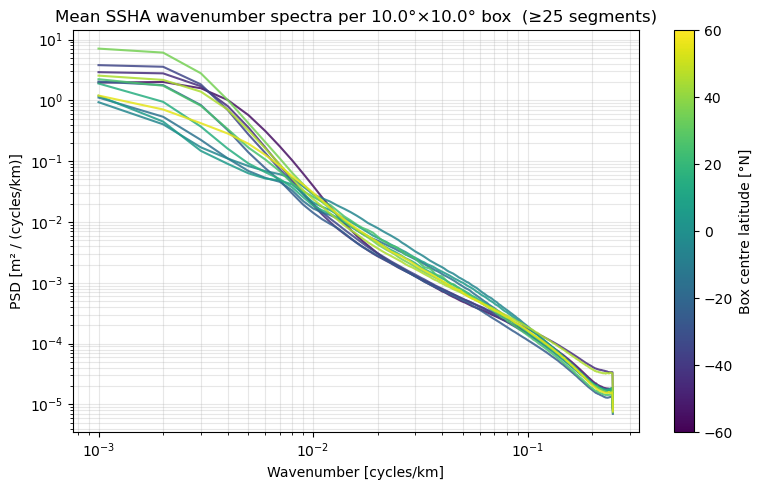

In [31]:
MIN_SEGMENTS_PER_BOX = 25
LAT_BIN_EDGES = np.arange(-60, 61, 10)  # adjust to the pass's latitude range

good_boxes = ds_boxes.where(ds_boxes["n_segments"] >= MIN_SEGMENTS_PER_BOX, drop=True)
#good_boxes = good_boxes.where((good_boxes["lat_center"] >= LAT_MIN)&(good_boxes["lat_center"] <= 47), drop=True)
print(f"{good_boxes.sizes['box']} boxes with ≥ {MIN_SEGMENTS_PER_BOX} segments")

binned = good_boxes.groupby_bins("lat_center", LAT_BIN_EDGES).mean()
lat_vals = binned["lat_center_bins"].values
norm = plt.Normalize(vmin=np.min(LAT_BIN_EDGES), vmax=np.max(LAT_BIN_EDGES))
cmap = plt.get_cmap("viridis")

box=binned

fig, ax = plt.subplots(figsize=(8, 5))
for i in range(box.sizes["lat_center_bins"]):
    lat_box = box.isel(lat_center_bins = i)
    ax.loglog(lat_box["wavenumber"][1:], lat_box["mean_psd"][1:],color=cmap(norm(float(lat_box["lat_center"]))),lw=1.5, alpha=0.85)


sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Box centre latitude [°N]")

ax.set_xlabel("Wavenumber [cycles/km]")
ax.set_ylabel("PSD [m² / (cycles/km)]")
ax.set_title(f"Mean SSHA wavenumber spectra per {BOX_DEG}°×{BOX_DEG}° box  "
             f"(≥{MIN_SEGMENTS_PER_BOX} segments)")

ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()


In [32]:
sub_boxes = ds_boxes.where((ds_boxes.lat_center>=30)& (ds_boxes.lat_center<=40),drop=True)

Text(0.1, 3, '-2')

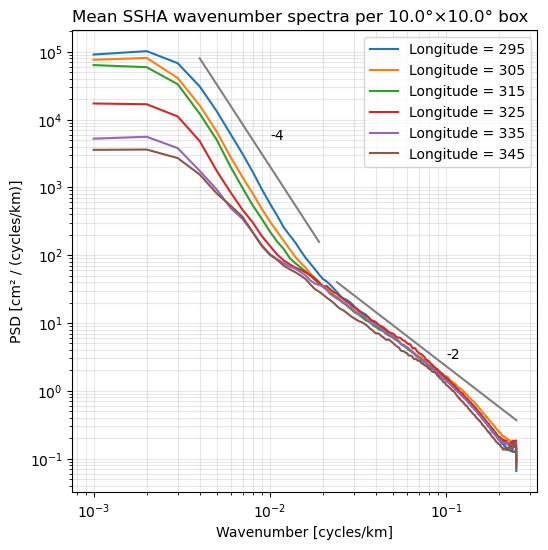

In [33]:
lon_centers = [295,305,315,325,335,345]
fig, ax = plt.subplots(figsize=(6, 6))
for l in lon_centers:
    psd_plot = sub_boxes.where(sub_boxes.lon_center==l,drop=True).mean_psd
    ax.loglog(psd_plot["wavenumber"][1:], psd_plot[0,1:]*1e4,label=f'Longitude = {l}')
    
ax.set_xlabel("Wavenumber [cycles/km]")
ax.set_ylabel("PSD [cm² / (cycles/km)]")
ax.set_title(f"Mean SSHA wavenumber spectra per {BOX_DEG}°×{BOX_DEG}° box  ")
ax.legend()
ax.grid(True, which="both", alpha=0.3)

# Reference slopes
k_ref = sub_boxes["wavenumber"].values[4:20]
k0    = k_ref[4]
psd0 = 5e3
ax.loglog(k_ref, psd0 * (k_ref / k0) ** -4,color='gray')
ax.text(0.01,5000,'-4')
k_ref = sub_boxes["wavenumber"].values[24:]
k0    = k_ref[24]
psd0 = 1e1
ax.loglog(k_ref, psd0 * (k_ref / k0) ** -2,color='gray')
ax.text(0.1,3,'-2')


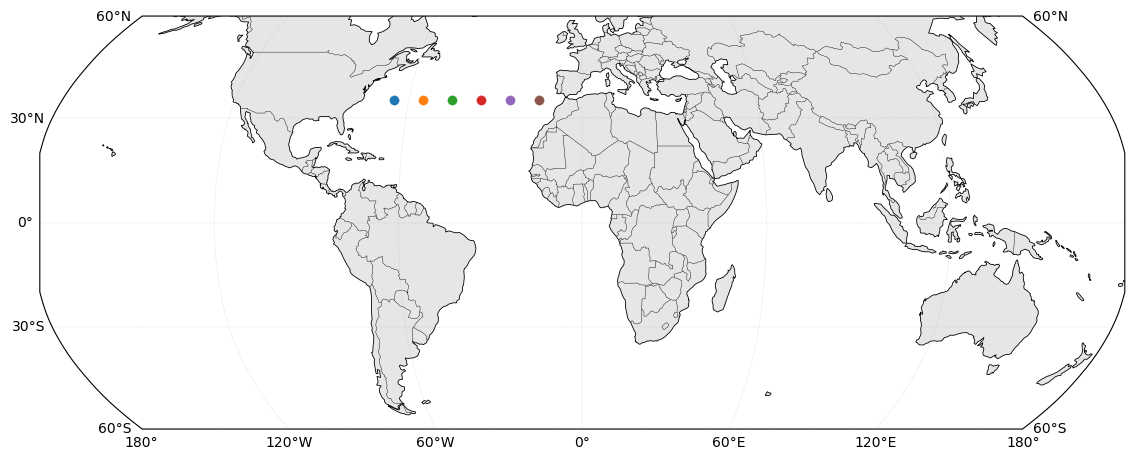

In [34]:
fig = plt.figure(figsize=((14, 7)))
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()
ax.add_feature(cfeature.LAND,facecolor="0.9",edgecolor="none")
ax.add_feature(cfeature.COASTLINE,linewidth=0.6)
ax.add_feature(cfeature.BORDERS,linewidth=0.3)
gl = ax.gridlines(draw_labels=True,linewidth=0.3,linestyle="--",alpha=0.5)
    
gl.top_labels = False
gl.right_labels = False

gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 60))
gl.ylocator = mticker.FixedLocator(np.arange(-60, 61, 30))

gl.xlabel_style = {"size": 10,"color": "black",}

gl.ylabel_style = {"size": 10,"color": "black",}
for l in lon_centers:
    ibox = sub_boxes.where(sub_boxes.lon_center==l,drop=True).box
    lat_center,lon_center = sub_boxes.lat_center.sel(box=ibox), sub_boxes.lon_center.sel(box=ibox)
    sc = ax.scatter(lon_center,lat_center,s=45,linewidths=0.25,
                transform=ccrs.PlateCarree())

ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
plt.show()

In [35]:
sub_boxes = ds_boxes.where((ds_boxes.lon_center>=310)& (ds_boxes.lon_center<=320),drop=True)

Text(0.1, 3, '-2')

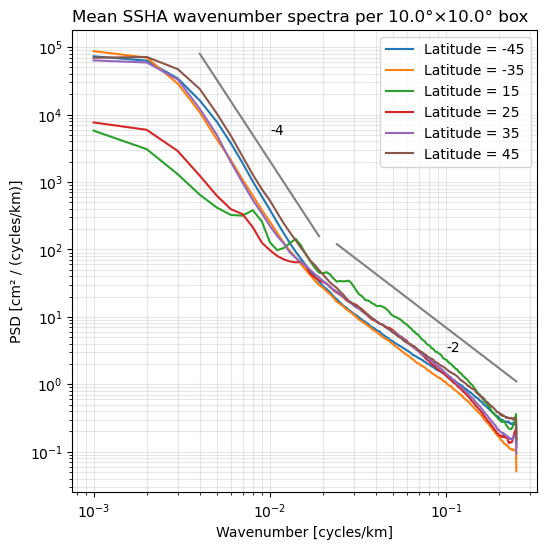

In [36]:
lat_centers = [-45,-35,15,25,35,45]
fig, ax = plt.subplots(figsize=(6, 6))
for l in lat_centers:
    psd_plot = sub_boxes.where(sub_boxes.lat_center==l,drop=True).mean_psd
    ax.loglog(psd_plot["wavenumber"][1:], psd_plot[0,1:]*1e4,label=f'Latitude = {l}')
    
ax.set_xlabel("Wavenumber [cycles/km]")
ax.set_ylabel("PSD [cm² / (cycles/km)]")
ax.set_title(f"Mean SSHA wavenumber spectra per {BOX_DEG}°×{BOX_DEG}° box  ")
ax.legend()
ax.grid(True, which="both", alpha=0.3)

# Reference slopes
k_ref = sub_boxes["wavenumber"].values[4:20]
k0    = k_ref[4]
psd0 = 5e3
ax.loglog(k_ref, psd0 * (k_ref / k0) ** -4,color='gray')
ax.text(0.01,5000,'-4')
k_ref = sub_boxes["wavenumber"].values[24:]
k0    = k_ref[24]
psd0 = 3e1
ax.loglog(k_ref, psd0 * (k_ref / k0) ** -2,color='gray')
ax.text(0.1,3,'-2')


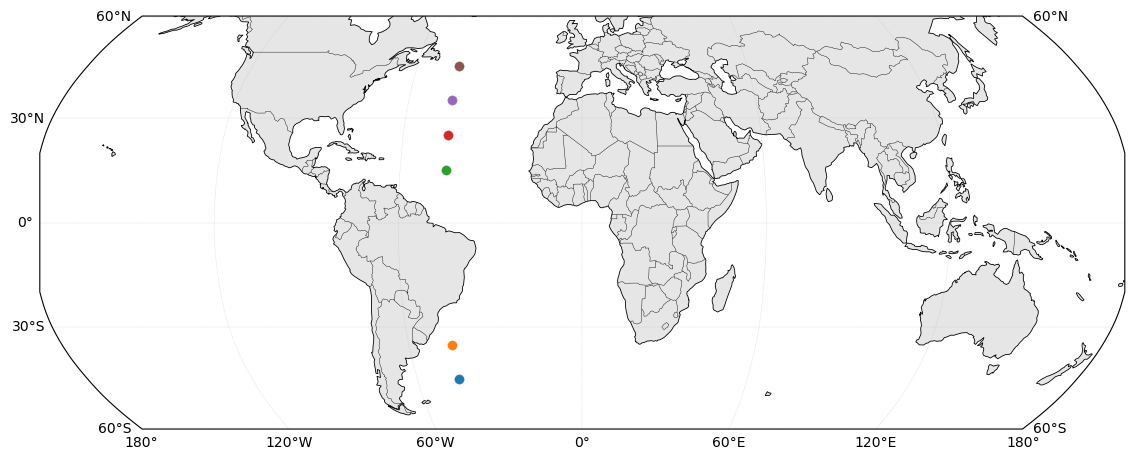

In [37]:
fig = plt.figure(figsize=((14, 7)))
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()
ax.add_feature(cfeature.LAND,facecolor="0.9",edgecolor="none")
ax.add_feature(cfeature.COASTLINE,linewidth=0.6)
ax.add_feature(cfeature.BORDERS,linewidth=0.3)
gl = ax.gridlines(draw_labels=True,linewidth=0.3,linestyle="--",alpha=0.5)
    
gl.top_labels = False
gl.right_labels = False

gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 60))
gl.ylocator = mticker.FixedLocator(np.arange(-60, 61, 30))

gl.xlabel_style = {"size": 10,"color": "black",}

gl.ylabel_style = {"size": 10,"color": "black",}
for l in lat_centers:
    ibox = sub_boxes.where(sub_boxes.lat_center==l,drop=True).box
    lat_center,lon_center = sub_boxes.lat_center.sel(box=ibox), sub_boxes.lon_center.sel(box=ibox)
    sc = ax.scatter(lon_center,lat_center,s=45,linewidths=0.25,
                transform=ccrs.PlateCarree())

ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
plt.show()

## Smaller scales

In [38]:
sub_boxes = ds_boxes_250.where((ds_boxes_250.lon_center>=310)& (ds_boxes_250.lon_center<=320),drop=True)

Text(0.1, 3, '-2')

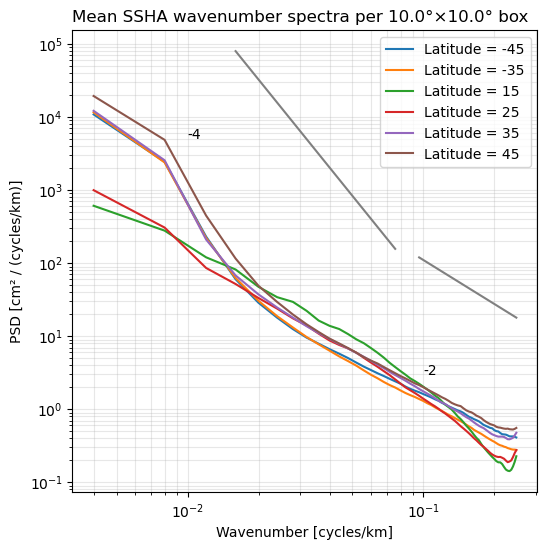

In [39]:
lat_centers = [-45,-35,15,25,35,45]
fig, ax = plt.subplots(figsize=(6, 6))
for l in lat_centers:
    psd_plot = sub_boxes.where(sub_boxes.lat_center==l,drop=True).mean_psd
    ax.loglog(psd_plot["wavenumber"][1:], psd_plot[0,1:]*1e4,label=f'Latitude = {l}')
    
ax.set_xlabel("Wavenumber [cycles/km]")
ax.set_ylabel("PSD [cm² / (cycles/km)]")
ax.set_title(f"Mean SSHA wavenumber spectra per {BOX_DEG}°×{BOX_DEG}° box  ")
ax.legend()
ax.grid(True, which="both", alpha=0.3)

# Reference slopes
k_ref = sub_boxes["wavenumber"].values[4:20]
k0    = k_ref[4]
psd0 = 5e3
ax.loglog(k_ref, psd0 * (k_ref / k0) ** -4,color='gray')
ax.text(0.01,5000,'-4')
k_ref = sub_boxes["wavenumber"].values[24:]
k0    = k_ref[24]
psd0 = 3e1
ax.loglog(k_ref, psd0 * (k_ref / k0) ** -2,color='gray')
ax.text(0.1,3,'-2')
